# Попарное сравнение прозаиков

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SergeyShk/ruTS/blob/master/examples/03_prose_authors.ipynb)

Набор [`RussianLiterature`](https://sergeyshk.github.io/ruTS/datasets/russianliterature/) - проза одиннадцати писателей XIX - начала XX века. В документации [`compare_corpora`](https://sergeyshk.github.io/ruTS/corpus/compare/) разобрана одна пара, Чехов против Толстого: многоточия, восклицания, доля личных форм глагола, длина предложения. Здесь та же процедура применяется ко всем парам: каждый автор режется на окна по 1000 слов, для окна считаются 130 признаков `text_features` (базовые, удобочитаемость, разнообразие, морфология, ритм предложений, пунктуация), а для каждой пары авторов и каждого признака - дельта Клиффа, размер эффекта, не зависящий от числа окон.

Вопросы: какие признаки различают каждую пару сильнее всего, есть ли признаки, которые работают на всех парах, кто из авторов ближе друг к другу и совпадает ли эта картина с классической стилометрией - дельтой Барроуза по самым частым словам.

## Установка и данные

В Colab ячейка ставит библиотеку; модель spaCy этому ноутбуку не нужна - признаки `text_features` считаются по razdel и pymorphy3. Набор `RussianLiterature` загружается один раз (архив 20 МБ с проверкой SHA-256).

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("ruts") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ruts"], check=True)

In [2]:
import pandas as pd

from ruts.datasets import RussianLiterature

rl = RussianLiterature()
rl.download()

prose = pd.DataFrame(
    {"author": r["author"].split()[-1], "title": r["title"], "chars": len(r["text"])}
    for r in rl.get_records(genre="prose")
)
overview = prose.groupby("author").agg(works=("title", "count"), chars=("chars", "sum"))
overview["thousand_words"] = (overview["chars"] / 6.5 / 1000).round()
overview.sort_values("chars", ascending=False)

,works,chars,thousand_words
author,,,
Достоевский,33,11220457,1726.0
Толстой,42,9391244,1445.0
Горький,33,4322978,665.0
Брюсов,30,2829399,435.0
Тургенев,10,2344841,361.0
Гоголь,16,2289073,352.0
Чехов,77,1832688,282.0
Герцен,11,1281853,197.0
Пушкин,10,931902,143.0


Объёмы различаются в сотни раз: у Достоевского 1.7 млн слов, у Блока - 6 тысяч. Блок исключён (меньше 30 окон), у остальных берётся не больше 200 окон, равномерно по всему тексту автора: так пары сравниваются на сопоставимом числе окон, а признаки считаются за минуту, а не за пять. Перед нарезкой в текстах схлопываются пробелы: файлы набора свёрстаны по-разному - у Брюсова и Герцена строки начинаются с отступа, у Тургенева перед тире стоит неразрывный пробел, - и без этого доли пробелов, букв и знаков (`basic_p_spaces`, `basic_p_letters`, `basic_p_punctuations`) измеряли бы вёрстку, а не текст.

In [3]:
import re

import numpy as np

from ruts.corpus import split_windows, text_features

WINDOW = 1000
MAX_WINDOWS = 200
MIN_WINDOWS = 30


def normalize_spaces(text: str) -> str:
    """Схлопывание отступов, двойных и неразрывных пробелов, переводы строк остаются"""
    return re.sub(r"[^\S\n]+", " ", re.sub(r"\s*\n\s*", "\n", text))


windows: dict[str, list[str]] = {}
for author in sorted(overview.index):
    author_windows = [
        window
        for text in rl.get_texts(genre="prose", author=author)
        for window in split_windows(normalize_spaces(text), WINDOW)
    ]
    if len(author_windows) < MIN_WINDOWS:
        print(f"{author}: {len(author_windows)} окон, пропущен")
        continue
    if len(author_windows) > MAX_WINDOWS:
        positions = np.linspace(0, len(author_windows) - 1, MAX_WINDOWS).round().astype(int)
        author_windows = [author_windows[position] for position in positions]
    windows[author] = author_windows

features = {
    author: pd.DataFrame([text_features(window) for window in author_windows]).astype(float)
    for author, author_windows in windows.items()
}
authors = list(features)
pd.Series({author: len(table) for author, table in features.items()}, name="окон").to_frame().T

Блок: 6 окон, пропущен


,Брюсов,Герцен,Гоголь,Горький,Достоевский,Лермонтов,Пушкин,Толстой,Тургенев,Чехов
окон,200,189,200,200,200,49,141,200,200,200


## Одна пара: Чехов против Толстого

`compare_features` - вторая половина `compare_corpora`: сравнивает две готовые таблицы признаков окон, для каждого признака критерий Манна-Уитни, дельта Клиффа, AUC и бутстрэп-интервал разности медиан, поправка Холма по всем признакам. Признаки посчитаны один раз, поэтому дальше так можно сравнить любую пару авторов без пересчёта. Топ по |дельте Клиффа| воспроизводит результат из документации, полученный на всех окнах: многоточия и восклицания Чехова, его короткие предложения и личные формы глагола, «сложность» Толстого по формулам удобочитаемости.

In [4]:
from ruts.corpus import compare_features

chekhov_tolstoy = compare_features(
    features["Чехов"], features["Толстой"], labels=("Чехов", "Толстой")
)
columns = ["median_Чехов", "median_Толстой", "ci_low", "ci_high", "cliff_delta", "auc", "p_holm"]
chekhov_tolstoy[columns].head(10).round(3)

,median_Чехов,median_Толстой,ci_low,ci_high,cliff_delta,auc,p_holm
punct_ellipsis,16.950,2.005,10.174,19.599,0.718,0.859,0.0
punct_exclamation,15.733,3.976,9.010,14.678,0.701,0.851,0.0
morph_verb_form_Fin,0.758,0.701,0.048,0.074,0.606,0.803,0.0
punct_yo_share,0.007,0.000,0.007,0.009,0.565,0.782,0.0
readability_gunning_fog_index,6.017,8.108,-2.487,-1.657,-0.542,0.229,0.0
readability_dale_chall_index,5.224,6.822,-2.157,-1.231,-0.537,0.232,0.0
readability_matskovsky_index,8.627,11.534,-3.533,-2.217,-0.529,0.235,0.0
readability_sis_grade,0.897,3.580,-3.233,-2.014,-0.529,0.235,0.0
readability_smog_index,5.705,7.352,-2.095,-1.130,-0.527,0.236,0.0
readability_rix,3.216,4.727,-1.861,-0.980,-0.526,0.237,0.0


## Все пары

Дельта Клиффа для 45 пар и 130 признаков считается за секунду. Порог большого эффекта - |δ| ≥ 0.474 (Romano et al., 2006; 0.147 - малый, 0.33 - средний). Число признаков с большим эффектом - грубая мера расстояния между авторами: у самых близких пар таких признаков 5-9, у самых далёких - 53-69.

In [5]:
from itertools import combinations

from ruts.corpus import calc_cliff_delta

LARGE = 0.474

pairs = list(combinations(authors, 2))
deltas = pd.DataFrame(index=features[authors[0]].columns, columns=pd.MultiIndex.from_tuples(pairs))
for author_a, author_b in pairs:
    table_a, table_b = features[author_a], features[author_b]
    for name in deltas.index:
        values_a = table_a[name].to_numpy()
        values_b = table_b[name].to_numpy()
        values_a, values_b = values_a[np.isfinite(values_a)], values_b[np.isfinite(values_b)]
        if len(values_a) > 1 and len(values_b) > 1:
            deltas.loc[name, (author_a, author_b)] = calc_cliff_delta(values_a, values_b)
deltas = deltas.astype(float)

n_large = (deltas.abs() >= LARGE).sum().sort_values()
print("самые близкие пары:", n_large.head(5).to_dict())
print("самые далёкие пары:", n_large.tail(5).to_dict())

самые близкие пары: {('Тургенев', 'Чехов'): 5, ('Гоголь', 'Тургенев'): 6, ('Достоевский', 'Толстой'): 8, ('Лермонтов', 'Тургенев'): 9, ('Брюсов', 'Герцен'): 11}
самые далёкие пары: {('Герцен', 'Толстой'): 53, ('Брюсов', 'Достоевский'): 57, ('Достоевский', 'Пушкин'): 58, ('Герцен', 'Чехов'): 59, ('Герцен', 'Достоевский'): 69}


Три признака с наибольшим эффектом для каждой пары. Знак дельты - в пользу первого автора пары: положительная дельта значит, что у него признак больше. Видно, что пары различают разные вещи: Пушкина от Гоголя - наречия, запятые и подчинительные союзы Гоголя; Толстого от Достоевского - наречия и частицы Достоевского против существительных и деепричастий Толстого.

In [6]:
def top_features(pair: tuple[str, str], n: int = 3) -> str:
    """Признаки пары с наибольшим |δ| в виде строки"""
    column = deltas[pair].dropna()
    strongest = column.reindex(column.abs().sort_values(ascending=False).index).head(n)
    return ", ".join(f"{name} {value:+.2f}" for name, value in strongest.items())


pd.DataFrame(
    {
        "признаков с |δ| ≥ 0.474": n_large,
        "сильнее всего": [top_features(pair) for pair in n_large.index],
    }
)

признаков с |δ| ≥ 0.474  \
Тургенев    Чехов                              5   
Гоголь      Тургенев                           6   
Достоевский Толстой                            8   
Лермонтов   Тургенев                           9   
Брюсов      Герцен                            11   
            Гоголь                            12   
Гоголь      Лермонтов                         12   
            Толстой                           14   
Лермонтов   Чехов                             15   
Горький     Лермонтов                         17   
Гоголь      Пушкин                            17   
Горький     Тургенев                          18   
Толстой     Чехов                             19   
Гоголь      Чехов                             19   
Пушкин      Тургенев                          22   
Брюсов      Пушкин                            26   
Гоголь      Горький                           27   
Герцен      Пушкин                            27   
            Гоголь                            28   
Горький     Чехов                             29   
Брюсов      Лермонтов                         30   
            Тургенев                          33   
Герцен      Тургенев                          34   
Достоевский Чехов                             34   
Толстой     Тургенев                          35   
Лермонтов   Пушкин                            38   
Брюсов      Толстой                           38   
Гоголь      Достоевский                       38   
Горький     Пушкин                            40   
Брюсов      Чехов                             41   
Достоевский Тургенев                          42   
Герцен      Горький                           44   
            Лермонтов                         45   
Горький     Достоевский                       46   
Пушкин      Толстой                           47   
Достоевский Лермонтов                         47   
Лермонтов   Толстой                           47   
Брюсов      Горький                           49   
Горький     Толстой                           51   
Пушкин      Чехов                             52   
Герцен      Толстой                           53   
Брюсов      Достоевский                       57   
Достоевский Пушкин                            58   
Герцен      Чехов                             59   
            Достоевский                       69   

                                                             сильнее всего  
Тургенев    Чехов        punct_semicolon +0.87, punct_yo_share -0.69, p...  
Гоголь      Тургенев     punct_ellipsis -0.73, morph_verb_form_Fin -0.6...  
Достоевский Толстой      morph_pos_ADV +0.71, morph_pos_PART +0.70, bas...  
Лермонтов   Тургенев     readability_reading_time -0.81, punct_angle_qu...  
Брюсов      Герцен       punct_semicolon -0.94, morph_person_1 +0.75, m...  
            Гоголь       punct_semicolon -0.81, morph_person_1 +0.80, p...  
Гоголь      Лермонтов    morph_pos_PRON -0.90, punct_semicolon -0.88, m...  
            Толстой      punct_colon +0.72, punct_exclamation +0.60, di...  
Лермонтов   Чехов        punct_semicolon +0.99, punct_colon +0.77, punc...  
Горький     Лермонтов    punct_semicolon -0.94, readability_reading_tim...  
Гоголь      Пушкин       morph_pos_ADV +0.85, punct_comma +0.81, morph_...  
Горький     Тургенев     morph_verb_form_Conv +0.78, punct_semicolon -0...  
Толстой     Чехов        punct_ellipsis -0.72, punct_exclamation -0.70,...  
Гоголь      Чехов        punct_ellipsis -0.70, punct_yo_share -0.66, pu...  
Пушкин      Тургенев     morph_pos_ADV -0.87, punct_ellipsis -0.78, mor...  
Брюсов      Пушкин       punct_semicolon -0.85, morph_pos_SCONJ +0.83, ...  
Гоголь      Горький      morph_pos_DET +0.81, punct_dash -0.71, punct_e...  
Герцен      Пушкин       punct_comma +0.94, punct_straight_quotes +0.93...  
            Гоголь       punct_straight_quotes +0.81, punct_angle_quote...  
Горький     Чехов        diversity_msttr +0.71, diversity_mattr +0.71, ...  
Брюсов      Лер

## Оформление против стиля

Часть признаков различает не авторов, а издания, из которых взяты тексты: вид кавычек (`punct_straight_quotes` и `punct_angle_quotes`) и доля буквы ё (`punct_yo_share`) зависят от того, кто и когда оцифровал книгу, а отступы и неразрывные пробелы без нормализации выше искажали бы доли пробелов и букв. У таких признаков большой эффект на многих парах, но это не стиль - кавычки и ё ниже исключены из оценок близости.

In [7]:
EDITORIAL = ["punct_straight_quotes", "punct_angle_quotes", "punct_yo_share"]
editorial_share = (deltas.loc[EDITORIAL].abs() >= LARGE).mean(axis=1)
editorial_share.round(2).to_frame("доля пар с большим эффектом")

,доля пар с большим эффектом
punct_straight_quotes,0.38
punct_angle_quotes,0.44
punct_yo_share,0.27


## Универсальные и парные признаки

Сколько раз признак попадает в десятку сильнейших по парам и каков его средний |δ| по всем 45 парам. Универсальных различителей немного: точка с запятой (в топ-10 у 22 пар из 45), многоточие, тире, оконные меры разнообразия (MATTR, MSTTR, P Баайена), запятые и восклицания, из морфологии - местоимения-определители, первое лицо и наречия. Большинство признаков различают лишь отдельные пары. По группам сильнее всего разнообразие и пунктуация, слабее всего морфология: половина её категорий (условное наклонение, средний залог, вспомогательные глаголы) в окне из 1000 слов почти не встречается и никого не различает.

In [8]:
style = deltas.drop(index=EDITORIAL)
in_top10 = pd.Series(0, index=style.index, dtype=int)
for pair in pairs:
    column = style[pair].dropna()
    in_top10[column.abs().sort_values(ascending=False).head(10).index] += 1
summary = pd.DataFrame(
    {"в топ-10 пар": in_top10, "средний |δ|": style.abs().mean(axis=1)}
).sort_values("в топ-10 пар", ascending=False)
summary.head(12).round(2)

,в топ-10 пар,средний |δ|
punct_semicolon,22,0.58
punct_ellipsis,16,0.48
punct_dash,11,0.43
diversity_mattr,11,0.46
diversity_baayen_p,11,0.42
punct_comma,10,0.41
morph_pos_DET,10,0.40
punct_exclamation,10,0.40
morph_person_1,9,0.35
diversity_msttr,9,0.44


In [9]:
groups = summary.index.str.split("_").str[0]
by_group = summary.groupby(groups)["средний |δ|"].agg(["count", "mean"])
by_group.sort_values("mean", ascending=False).round(2)

,count,mean
diversity,32,0.40
punct,11,0.38
basic,12,0.35
readability,13,0.34
sents,4,0.29
morph,55,0.23


## Близость авторов

Расстояние между авторами - средний |δ| по стилевым признакам: чем больше признаков расходятся сильно, тем дальше авторы. По этой матрице строятся дендрограмма Уорда и многомерное шкалирование - те же функции, что для дельты Барроуза, потому что на входе просто матрица расстояний. Три группы: повествовательная проза (Чехов, Гоголь, Тургенев, Лермонтов, Горький), романы Толстого и Достоевского и особняком Герцен, Брюсов и Пушкин - у последних самые длинные слова из десяти авторов (медиана 5.1-5.3 буквы против 4.9-5.0 у Чехова и Достоевского), больше сложных слов и выше класс удобочитаемости, меньше наречий, тире и многоточий: книжная проза без разговорной экспрессии.

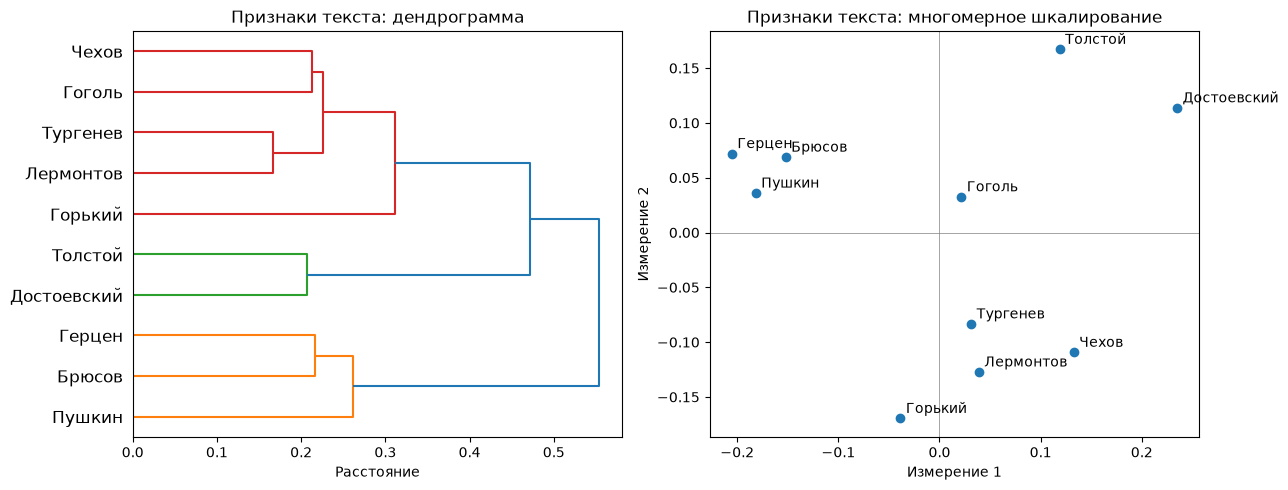

In [10]:
import matplotlib.pyplot as plt

from ruts.visualizers import dendrogram_plot, mds_plot

distance = pd.DataFrame(0.0, index=authors, columns=authors)
for (author_a, author_b), value in style.abs().mean().items():
    distance.loc[author_a, author_b] = distance.loc[author_b, author_a] = value

fig, (ax_tree, ax_mds) = plt.subplots(1, 2, figsize=(13, 5))
dendrogram_plot(distance, ax=ax_tree)
ax_tree.set_title("Признаки текста: дендрограмма")
mds_plot(distance, ax=ax_mds)
ax_mds.set_title("Признаки текста: многомерное шкалирование")
fig.tight_layout()

In [11]:
closest = {author: distance.loc[author].drop(author).idxmin() for author in authors}
pd.Series(closest, name="ближайший автор").to_frame()

,ближайший автор
Брюсов,Герцен
Герцен,Брюсов
Гоголь,Тургенев
Горький,Тургенев
Достоевский,Толстой
Лермонтов,Тургенев
Пушкин,Брюсов
Толстой,Достоевский
Тургенев,Лермонтов
Чехов,Тургенев


## Сверка с дельтой Барроуза

Классическая стилометрия смотрит не на признаки текста, а на частоты самых употребительных слов: дельта Барроуза - манхэттенское расстояние между z-оценками частот. Считаем её по тем же окнам (300 самых частых словоформ) и сравниваем две матрицы расстояний: корреляция Спирмена между их верхними треугольниками показывает, насколько согласны два взгляда на близость авторов. 45 попарных расстояний - зависимые наблюдения, и p-значение обычного критерия для них не работает, поэтому значимость проверяется тестом Мантеля: порядок авторов в одной матрице перемешивается 10 000 раз, и считается, как часто случайная корреляция не меньше наблюдаемой.

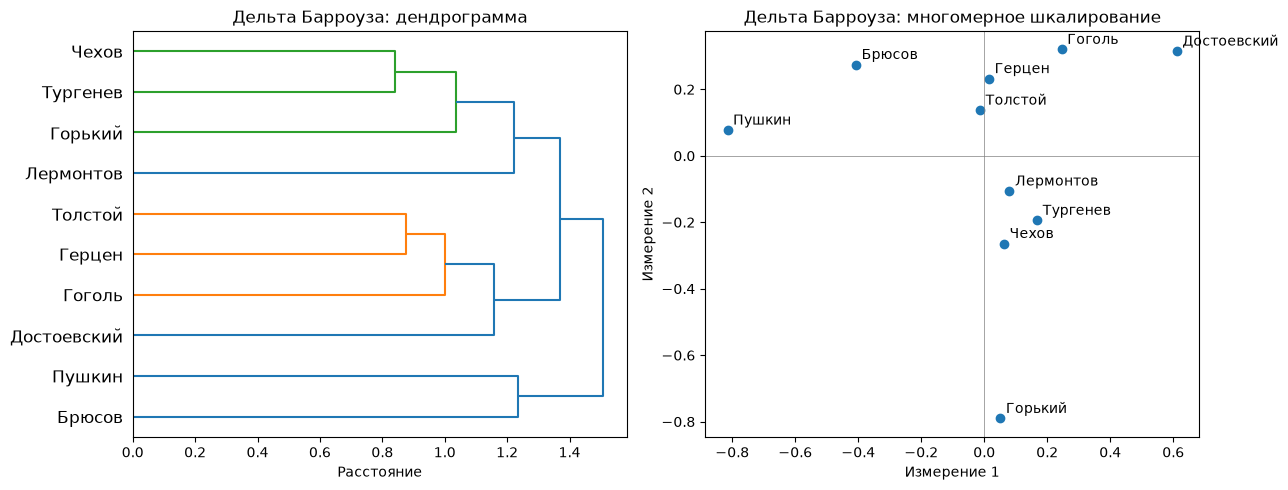

In [12]:
from ruts import WordsExtractor
from ruts.corpus import delta

extractor = WordsExtractor(lowercase=True)
corpus_words = {
    author: extractor.extract("\n".join(author_windows))
    for author, author_windows in windows.items()
}
burrows = delta(corpus_words, n_mfw=300)

fig, (ax_tree, ax_mds) = plt.subplots(1, 2, figsize=(13, 5))
dendrogram_plot(burrows, ax=ax_tree)
ax_tree.set_title("Дельта Барроуза: дендрограмма")
mds_plot(burrows, ax=ax_mds)
ax_mds.set_title("Дельта Барроуза: многомерное шкалирование")
fig.tight_layout()

In [13]:
from scipy.stats import spearmanr

upper = np.triu_indices(len(authors), k=1)
burrows = burrows.loc[authors, authors]
observed = spearmanr(distance.to_numpy()[upper], burrows.to_numpy()[upper]).statistic

rng = np.random.default_rng(0)
burrows_values = burrows.to_numpy()
permuted = []
for _ in range(10_000):
    order = rng.permutation(len(authors))
    shuffled = burrows_values[np.ix_(order, order)]
    permuted.append(spearmanr(distance.to_numpy()[upper], shuffled[upper]).statistic)
p_mantel = (np.array(permuted) >= observed).mean()
print(f"ρ Спирмена между матрицами расстояний: {observed:.2f}, p по тесту Мантеля: {p_mantel:.3f}")
pd.DataFrame(
    {
        "по признакам": pd.Series(closest),
        "по дельте Барроуза": pd.Series(
            {author: burrows.loc[author].drop(author).idxmin() for author in authors}
        ),
    }
)

ρ Спирмена между матрицами расстояний: 0.28, p по тесту Мантеля: 0.082


,по признакам,по дельте Барроуза
Брюсов,Герцен,Толстой
Герцен,Брюсов,Толстой
Гоголь,Тургенев,Герцен
Горький,Тургенев,Чехов
Достоевский,Толстой,Тургенев
Лермонтов,Тургенев,Тургенев
Пушкин,Брюсов,Герцен
Толстой,Достоевский,Герцен
Тургенев,Лермонтов,Чехов
Чехов,Тургенев,Тургенев


Согласие двух матриц ρ ≈ 0.3 при p ≈ 0.08 по тесту Мантеля - от случайного не отличается. Совпадают отдельные пары (Чехов-Тургенев, Лермонтов-Тургенев), но Толстой по частым словам ближе к Герцену, а не к Достоевскому, Пушкин - к Герцену, а не к Брюсову. Признаки текста измеряют манеру - длину предложения, пунктуацию, разнообразие, - а дельта Барроуза употребление служебных слов; это разные измерения, и для атрибуции авторства их стоит сочетать, а не выбирать одно.

## Итоги

*   Результат из документации для пары Чехов-Толстой воспроизводится на выборке из 200 окон: многоточия (δ = 0.72) и восклицания (0.70) Чехова, доля личных форм глагола (0.61), короткие предложения и формулы удобочитаемости в пользу Толстого (−0.55).
*   Расстояние между авторами по числу признаков с большим эффектом - от 5 (Тургенев-Чехов) до 69 (Герцен-Достоевский); каждую пару различают свои признаки.
*   Вид кавычек, доля буквы ё, отступы и неразрывные пробелы различают издания, а не авторов: пробелы надо схлопывать до нарезки на окна, признаки кавычек и ё - исключать из стилевого сравнения.
*   Универсальных различителей немного: точка с запятой, многоточие, тире, оконные меры разнообразия, запятые и восклицания; по группам сильнее всего разнообразие и пунктуация, слабее всего морфология.
*   По признакам текста авторы делятся на повествовательную прозу (Чехов, Гоголь, Тургенев, Лермонтов, Горький), романы Толстого и Достоевского и книжную группу Герцен-Брюсов-Пушкин с самыми длинными словами; дельта Барроуза по частым словам даёт другую картину (ρ ≈ 0.3, p ≈ 0.08 по Мантелю) - признаки текста и частые слова измеряют разное.